<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_2_LANDUSE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# ============================================================
# IMPORTS GENERALES
# ============================================================

# Manejo numérico
import numpy as np

# Procesamiento de imágenes
import cv2

# Sistema
import os
import random
import time

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab
from google.colab import drive
from google.colab.patches import cv2_imshow

# Machine Learning
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# Deep Learning
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [55]:
# ============================================================
# CONECTAR GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive', force_remount=True)


# ============================================================
# CONFIGURACIÓN DEL DATASET
# IMPORTANTE:
# Las mismas clases deben usarse en los 3 modelos
# para que la comparación sea justa
# ============================================================

base_path = '/content/drive/MyDrive/Reto 4 Vision/landuse/'

# Clases seleccionadas
subfolders = ['buildings', 'airplane', 'river']

Mounted at /content/drive


MODELO 1

In [56]:
# ============================================================
# MODELO 1 - MACHINE LEARNING BÁSICO
# ============================================================
# Este modelo usa características simples:
# Promedio y desviación estándar de RGB
# ============================================================

data_ml = []
labels_ml = []
paths_ml = []

for subfolder in subfolders:

    print("Cargando:", subfolder)

    path = os.path.join(base_path, subfolder)

    files = [f for f in os.listdir(path) if f.endswith('.png')]

    for file in files:

        img_path = os.path.join(path, file)

        paths_ml.append(img_path)

        img = cv2.imread(img_path)

        # Separar canales
        B, G, R = cv2.split(img)

        # Características básicas
        features = [
            np.mean(R), np.mean(G), np.mean(B),
            np.std(R), np.std(G), np.std(B)
        ]

        data_ml.append(features)
        labels_ml.append(subfolder)

Cargando: buildings
Cargando: airplane
Cargando: river


In [57]:
# ============================================================
# ETIQUETAS Y DIVISIÓN
# ============================================================

le_ml = LabelEncoder()
labels_ml = le_ml.fit_transform(labels_ml)

trainX_ml, testX_ml, trainY_ml, testY_ml = train_test_split(
    np.array(data_ml),
    np.array(labels_ml),
    test_size=0.25,
    random_state=42
)


# ============================================================
# MODELO RANDOM FOREST
# ============================================================

model_ml = RandomForestClassifier(random_state=42)

start_ml = time.time()

model_ml.fit(trainX_ml, trainY_ml)

end_ml = time.time()


===== REPORTE MODELO 1 =====
              precision    recall  f1-score   support

    airplane       0.51      0.51      0.51       115
   buildings       0.60      0.65      0.62       125
       river       0.74      0.69      0.72       135

    accuracy                           0.62       375
   macro avg       0.62      0.62      0.62       375
weighted avg       0.63      0.62      0.62       375

Accuracy: 62.133333333333326


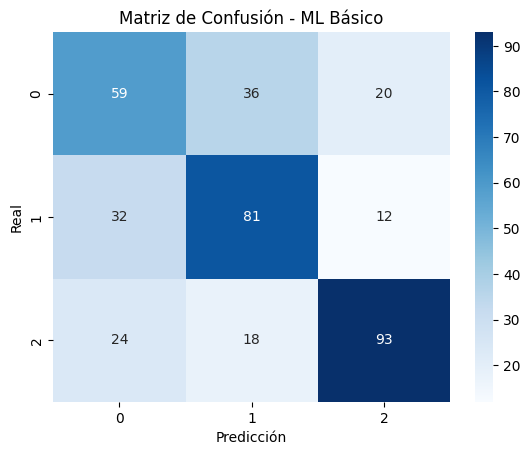

In [58]:
# ============================================================
# PREDICCIÓN Y REPORTE
# ============================================================

pred_ml = model_ml.predict(testX_ml)

acc_ml = accuracy_score(testY_ml, pred_ml)

print("\n===== REPORTE MODELO 1 =====")
print(classification_report(
    testY_ml,
    pred_ml,
    target_names=le_ml.classes_
))

print("Accuracy:", acc_ml * 100)


# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================

cm_ml = confusion_matrix(testY_ml, pred_ml)

plt.figure()
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - ML Básico")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Ground Truth: river
Predicted: river


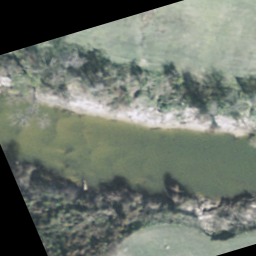

In [59]:
# ============================================================
# PREDICCIÓN ALEATORIA
# ============================================================

rand_pos = random.randint(0, len(paths_ml)-1)

img = cv2.imread(paths_ml[rand_pos])

B, G, R = cv2.split(img)

feature = [
    np.mean(R), np.mean(G), np.mean(B),
    np.std(R), np.std(G), np.std(B)
]

pred = model_ml.predict([feature])

print("Ground Truth:", paths_ml[rand_pos].split('/')[-2])
print("Predicted:", le_ml.classes_[pred][0])

cv2_imshow(img)

MODELO 2

In [60]:
# ============================================================
# MODELO 2 - MACHINE LEARNING + DESCRIPTORES
# ============================================================
# Se agregan características LAB para mejorar
# representación de color
# ============================================================

data_desc = []
labels_desc = []
paths_desc = []

for subfolder in subfolders:

    print("Cargando:", subfolder)

    path = os.path.join(base_path, subfolder)

    files = [f for f in os.listdir(path) if f.endswith('.png')]

    for file in files:

        img_path = os.path.join(path, file)

        paths_desc.append(img_path)

        img = cv2.imread(img_path)

        # RGB
        B, G, R = cv2.split(img)

        # LAB
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        L, A, BY = cv2.split(lab)

        # Features extendidas
        features = [
            np.mean(R), np.mean(G), np.mean(B),
            np.std(R), np.std(G), np.std(B),

            np.mean(L), np.mean(A), np.mean(BY),
            np.std(L), np.std(A), np.std(BY)
        ]

        data_desc.append(features)
        labels_desc.append(subfolder)

Cargando: buildings
Cargando: airplane
Cargando: river


In [61]:
le_desc = LabelEncoder()
labels_desc = le_desc.fit_transform(labels_desc)

trainX_desc, testX_desc, trainY_desc, testY_desc = train_test_split(
    np.array(data_desc),
    np.array(labels_desc),
    test_size=0.25,
    random_state=42
)

model_desc = RandomForestClassifier(random_state=42)

start_desc = time.time()

model_desc.fit(trainX_desc, trainY_desc)

end_desc = time.time()


===== REPORTE MODELO 2 =====
              precision    recall  f1-score   support

    airplane       0.68      0.74      0.71       115
   buildings       0.73      0.72      0.73       125
       river       0.85      0.80      0.82       135

    accuracy                           0.75       375
   macro avg       0.75      0.75      0.75       375
weighted avg       0.76      0.75      0.76       375

Accuracy: 75.46666666666667


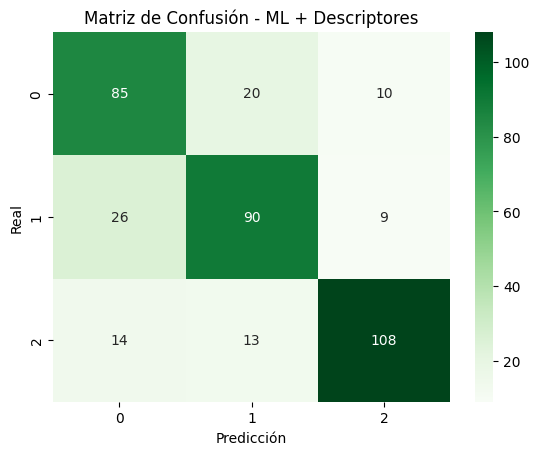

In [62]:
pred_desc = model_desc.predict(testX_desc)

acc_desc = accuracy_score(testY_desc, pred_desc)

print("\n===== REPORTE MODELO 2 =====")
print(classification_report(
    testY_desc,
    pred_desc,
    target_names=le_desc.classes_
))

print("Accuracy:", acc_desc * 100)


cm_desc = confusion_matrix(testY_desc, pred_desc)

plt.figure()
sns.heatmap(cm_desc, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - ML + Descriptores")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

Ground Truth: airplane
Predicted: airplane


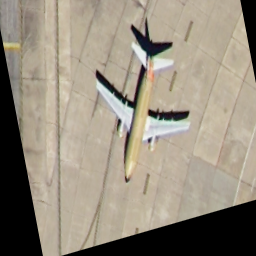

In [63]:
rand_pos = random.randint(0, len(paths_desc)-1)

img = cv2.imread(paths_desc[rand_pos])

B, G, R = cv2.split(img)

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, A, BY = cv2.split(lab)

feature = [
    np.mean(R), np.mean(G), np.mean(B),
    np.std(R), np.std(G), np.std(B),

    np.mean(L), np.mean(A), np.mean(BY),
    np.std(L), np.std(A), np.std(BY)
]

pred = model_desc.predict([feature])

print("Ground Truth:", paths_desc[rand_pos].split('/')[-2])
print("Predicted:", le_desc.classes_[pred][0])

cv2_imshow(img)

MODELO 3

In [64]:
# ============================================================
# BLOQUE COMPLETO Y CORREGIDO - CNN SECUENCIAL PROPIA
# ============================================================
# Este bloque incluye TODO:
# 1. Cargar imágenes
# 2. Preprocesar
# 3. Separar train/test
# 4. Crear CNN
# 5. Entrenar
# 6. Evaluar

# ------------------------------------------------------------
# IMPORTACIONES
# ------------------------------------------------------------
import os
import cv2
import time
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ------------------------------------------------------------
# GOOGLE DRIVE
# ------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ------------------------------------------------------------
# RUTAS DEL DATASET
# ------------------------------------------------------------
base_path = '/content/drive/MyDrive/Reto 4 Vision/'
folder = 'landuse/'
subfolders = ['buildings', 'airplane', 'river'] # Corrected subfolders to match available data

# ------------------------------------------------------------
# CARGAR IMÁGENES
# ------------------------------------------------------------
data = []
labels = []

for subfolder in subfolders:
    path_folder = os.path.join(base_path, folder, subfolder)

    files = [f for f in os.listdir(path_folder) if f.endswith('.png')]

    for file in files:
        path_img = os.path.join(path_folder, file)

        # Leer imagen
        img = cv2.imread(path_img)

        # Redimensionar a tamaño esperado por CNN
        img = cv2.resize(img, (224, 224))

        # Convertir BGR a RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Guardar
        data.append(img)
        labels.append(subfolder)

# Convertir a numpy
data = np.array(data, dtype="float32") / 255.0

# ------------------------------------------------------------
# CODIFICAR ETIQUETAS
# ------------------------------------------------------------
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# ------------------------------------------------------------
trainX, testX, trainY, testY = train_test_split(
    data,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

# ------------------------------------------------------------
# DATA AUGMENTATION
# ------------------------------------------------------------
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

# ------------------------------------------------------------
# MODELO CNN
# ------------------------------------------------------------
model_cnn = Sequential()

# Bloque 1
model_cnn.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Bloque 2
model_cnn.add(Conv2D(64, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Bloque 3
model_cnn.add(Conv2D(128, (3,3), activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2,2)))

# Clasificador
model_cnn.add(Flatten())
model_cnn.add(Dense(256, activation='relu'))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(3, activation='softmax'))

# ------------------------------------------------------------
# COMPILAR
# ------------------------------------------------------------
model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ------------------------------------------------------------
# ENTRENAR
# ------------------------------------------------------------
start_cnn = time.time()

H_cnn = model_cnn.fit(
    datagen.flow(trainX, trainY, batch_size=32),
    validation_data=(testX, testY),
    epochs=15
)

end_cnn = time.time()

# ------------------------------------------------------------
# EVALUACIÓN
# ------------------------------------------------------------
pred_cnn = model_cnn.predict(testX)

pred_labels = np.argmax(pred_cnn, axis=1)
true_labels = np.argmax(testY, axis=1)

acc_cnn = accuracy_score(true_labels, pred_labels)

# ------------------------------------------------------------
# REPORTE FINAL
# ------------------------------------------------------------
print("\n===== REPORTE MODELO 3 - CNN ====")
print(classification_report(
    true_labels,
    pred_labels,
    target_names=lb.classes_
))

print("Accuracy CNN: {:.2f}%".format(acc_cnn * 100))
print("Tiempo CNN: {:.2f} segundos".format(end_cnn - start_cnn))

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 29s 638ms/step - accuracy: 0.6178 - loss: 2.2860 - val_accuracy: 0.3333 - val_loss: 2.2826
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 448ms/step - accuracy: 0.6844 - loss: 0.9444 - val_accuracy: 0.3387 - val_loss: 1.5781
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 425ms/step - accuracy: 0.7218 - loss: 0.8005 - val_accuracy: 0.4773 - val_loss: 1.6558
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 435ms/step - accuracy: 0.7618 - loss: 0.6465 - val_accuracy: 0.5147 - val_loss: 3.1385
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 430ms/step - accuracy: 0.7680 - loss: 0.6046 - val_accuracy: 0.5093 - val_loss: 4.4604
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 434ms/step - accuracy: 0.7760 - loss: 0.5861 - val_accuracy: 0.4187 - val_loss: 6.4381
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 423ms/step - accuracy: 0.7893 - loss: 0.5808 - val_accuracy: 0.4373 - val_loss: 6.2215
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 427ms/step - accuracy: 0.8000 - loss: 0.5012 - val_accu

MODELO 4

In [65]:
# Listas para guardar imágenes y sus etiquetas
data = []
labels = []

# =========================
# CARGA DE IMÁGENES
# =========================

# Recorrer cada clase
for subfolder in subfolders:
    print('Cargando:', subfolder)

    # Construir la ruta de cada carpeta, incluyendo la carpeta 'landuse'
    path = os.path.join(base_path, 'landuse', subfolder)

    # Obtener solo las imágenes .png
    files = [f for f in os.listdir(path) if f.endswith('.png')]

    # Leer cada imagen
    for file in files:
        img = cv2.imread(os.path.join(path, file))  # Cargar imagen
        img = cv2.resize(img, (224,224))            # Redimensionar
        img = img.astype('float32') / 255.0         # Normalizar

        data.append(img)        # Guardar imagen
        labels.append(subfolder)  # Guardar etiqueta

# Convertir listas a arreglos de numpy
data = np.array(data)
labels = np.array(labels)

Cargando: buildings
Cargando: airplane
Cargando: river


In [66]:
# =========================
# PREPROCESAMIENTO
# =========================

# Convertir las etiquetas de texto a formato numérico
lb = LabelBinarizer()
labels = lb.fit_transform(labels)

# Dividir los datos en entrenamiento (75%) y prueba (25%)
(trainX, testX, trainY, testY) = train_test_split(
    data, labels, test_size=0.25, random_state=42
)

In [67]:
# =========================
# MODELO RESNET (TRANSFER LEARNING)
# =========================

# Cargar modelo ResNet50 preentrenado (sin la parte final)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Congelar la mayoría de capas y dejar algunas para entrenamiento (fine-tuning)
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Agregar capas propias para la clasificación
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(3, activation='softmax')(x)

# Definir el modelo final
model = Model(inputs=base_model.input, outputs=output)

# Mostrar la estructura del modelo
model.summary()

# Compilar el modelo
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

Model: "functional_44"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,539 (92.11 MB)

 Trainable params: 16,389,635 (62.52 MB)

 Non-trainable params: 7,755,904 (29.59 MB)

In [68]:
# =========================
# ENTRENAMIENTO
# =========================

# Generador de imágenes para aplicar aumentos (data augmentation)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,      # Rotación de imágenes
    zoom_range=0.2,         # Zoom
    horizontal_flip=True,   # Volteo horizontal
    shear_range=0.1         # Deformación ligera
)

# Ajustar el generador a los datos de entrenamiento
datagen.fit(trainX)

H = model.fit(
    datagen.flow(trainX, trainY, batch_size=32),
    validation_data=(testX, testY),
    epochs=25,
)

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.5227 - loss: 0.9684 - val_accuracy: 0.3067 - val_loss: 1.1410
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 469ms/step - accuracy: 0.6640 - loss: 0.7633 - val_accuracy: 0.3120 - val_loss: 1.1627
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 468ms/step - accuracy: 0.7191 - loss: 0.6756 - val_accuracy: 0.3120 - val_loss: 1.1321
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 478ms/step - accuracy: 0.7600 - loss: 0.5986 - val_accuracy: 0.4800 - val_loss: 1.0082
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 18s 492ms/step - accuracy: 0.7724 - loss: 0.5563 - val_accuracy: 0.7253 - val_loss: 0.8566
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 472ms/step - accuracy: 0.7929 - loss: 0.5170 - val_accuracy: 0.7813 - val_loss: 0.7181
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 473ms/step - accuracy: 0.7831 - loss: 0.5138 - val_accuracy: 0.7840 - val_loss: 0.6153
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 473ms/step - accuracy: 0.8089 - loss: 0.4726 - val_accurac

In [69]:
# ============================================================
# EVALUACIÓN - ResNet
# ============================================================
start_resnet = time.time()
predictions = model.predict(testX)
end_resnet = time.time()

acc_resnet = accuracy_score(testY.argmax(axis=1), predictions.argmax(axis=1))

print("\n===== REPORTE MODELO 4 - ResNet =====")
print(classification_report(
    testY.argmax(axis=1),
    predictions.argmax(axis=1),
    target_names=lb.classes_
))

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 462ms/step

===== REPORTE MODELO 4 - ResNet =====
              precision    recall  f1-score   support

    airplane       0.80      0.89      0.84       115
   buildings       0.83      0.88      0.85       125
       river       1.00      0.84      0.92       135

    accuracy                           0.87       375
   macro avg       0.87      0.87      0.87       375
weighted avg       0.88      0.87      0.87       375



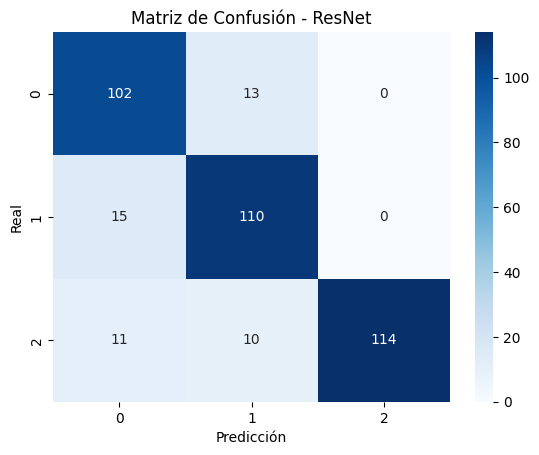

In [70]:
# =========================
# MATRIZ DE CONFUSIÓN
# =========================

# Calcular la matriz de confusión
cm = confusion_matrix(
    testY.argmax(axis=1),        # Clases reales
    predictions.argmax(axis=1)   # Clases predichas
)

# Visualizar la matriz de confusión
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # Mostrar valores en la matriz
plt.title("Matriz de Confusión - ResNet")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

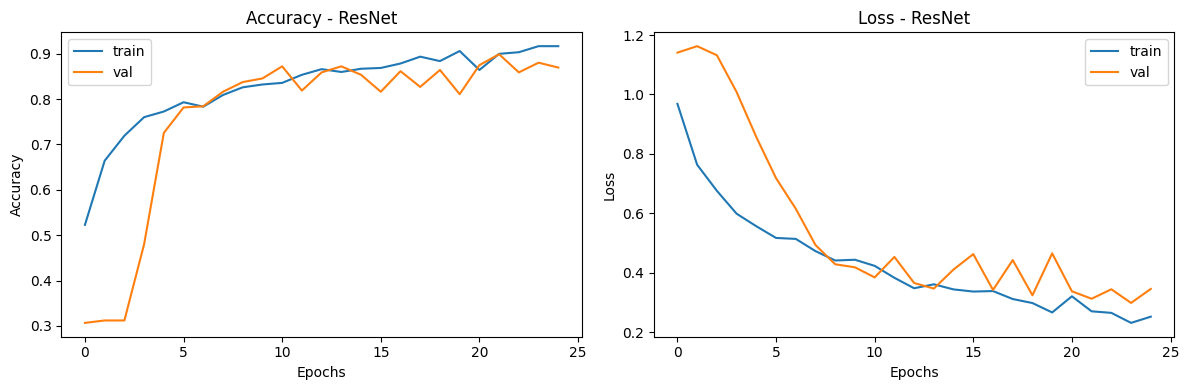

In [71]:
# ============================================================
# GRÁFICAS DE ENTRENAMIENTO - ResNet
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(H.history['accuracy'], label='train')
axes[0].plot(H.history['val_accuracy'], label='val')
axes[0].set_title("Accuracy - ResNet")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(H.history['loss'], label='train')
axes[1].plot(H.history['val_loss'], label='val')
axes[1].set_title("Loss - ResNet")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

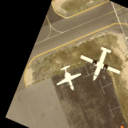

Ground truth class:  airplane
Predicted class:  airplane


In [72]:
# Mostrar una imagen aleatoria y su predicción

from google.colab.patches import cv2_imshow
import random

# Seleccionar una posición aleatoria del conjunto de prueba
rand_pos = random.randint(0, len(testX) - 1)

# Obtener la imagen correspondiente
rand_img = testX[rand_pos]

# Ajustar la imagen para visualizarla correctamente
rand_img_resized = 255 * cv2.resize(rand_img, (128, 128))

# Mostrar la imagen
cv2_imshow(rand_img_resized)

# Mostrar la clase real y la predicha por el modelo
print('Ground truth class: ', lb.classes_[np.argmax(testY[rand_pos])])
print('Predicted class: ', lb.classes_[np.argmax(predictions[rand_pos])])

Modelo                 Accuracy   Tiempo (s)
ML Básico                62.13%        0.43s
ML + Descriptores        75.47%        0.52s
CNN Propia               80.27%      250.51s
ResNet50                 86.93%       10.85s


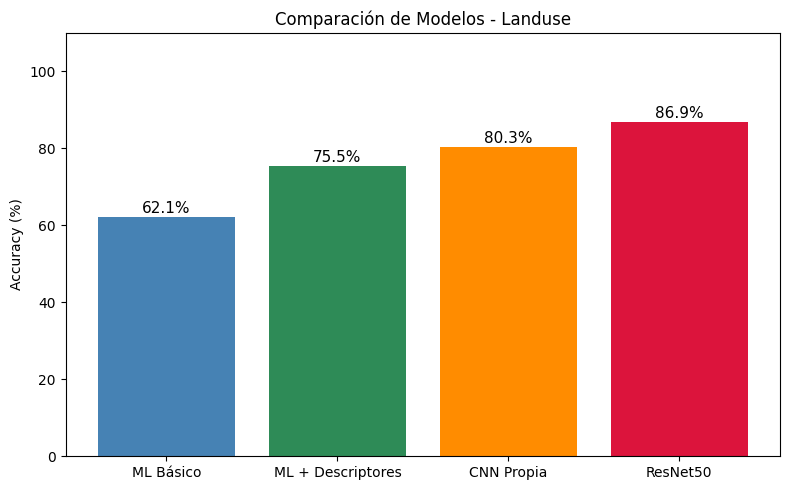

In [73]:
# ============================================================
# COMPARACIÓN FINAL DE TODOS LOS MODELOS
# ============================================================
modelos = ['ML Básico', 'ML + Descriptores', 'CNN Propia', 'ResNet50']
accuracies = [acc_ml * 100, acc_desc * 100, acc_cnn * 100, acc_resnet * 100]
tiempos = [
    end_ml - start_ml,
    end_desc - start_desc,
    end_cnn - start_cnn,
    end_resnet - start_resnet
]

print("=" * 50)
print(f"{'Modelo':<20} {'Accuracy':>10} {'Tiempo (s)':>12}")
print("=" * 50)
for m, a, t in zip(modelos, accuracies, tiempos):
    print(f"{m:<20} {a:>9.2f}% {t:>11.2f}s")
print("=" * 50)

# Gráfica de barras
plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accuracies, color=['steelblue', 'seagreen', 'darkorange', 'crimson'])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.title("Comparación de Modelos - Landuse")
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha='center', fontsize=11)
plt.tight_layout()
plt.show()